# Topic analysis Citations v2
## Expressions and evidence for saved citation communities

Explore the **direct-citation Leiden communities** from `Clustering PDFs.ipynb`
with the same term tables, expression search, coverage plots and source passages
as the PDF and abstracts v2 notebooks. No topic names are loaded or generated.

The default is the **saved `citation_r0.9` partition**: **five communities**, selected
seed **44**, with **289 assigned works** and **3 isolated works unassigned**.
The catalog includes all **23 saved source resolutions, 0.10–1.20 in steps of 0.05**.
It imports the exact saved seed memberships and checks their graph, identities,
selection rule and diagnostics. Loading and selecting saved partitions performs
no clustering.

The reviewed graph covers **292 canonical works**, mapped from 294 PDFs; duplicate
aliases count once. Directed citations, including reviewed manual links, are
converted to a binary undirected union for Leiden. Topic evidence comes from each
canonical work's retained PDF text. Citation structure defines the memberships;
the text helps you interpret them.

**Reading order:** choose a saved partition → compare expressions → review two papers per
community → inspect a community → trace an expression to source pages → optionally export the evidence.


## 1 Load the citation corpus and list saved partitions

Use the project **Python (batill)** kernel. The loader checks retained PDF text,
reviewed graph files, paper identities and the saved source sweep. It creates
validated assignment snapshots from the saved memberships on first use and reuses
those snapshots afterwards. Existing source files and earlier analyses are preserved.

The table reports citation modularity at gamma = 1 and agreement across source
seeds. These are graph diagnostics; they are not embedding cosine silhouettes.
Unlinked works receive cluster 0 and are excluded from term contrasts.


In [1]:
from pathlib import Path
from html import escape
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML

candidates = [Path.cwd(), Path.cwd() / 'batill', *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / 'src/batill').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook from the batill project.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
# Refresh helpers when rerunning in an existing notebook kernel.
from importlib import reload
import batill.topic_analysis as topic_analysis
import batill.topic_explorer as shared_topic_explorer
import batill.citation_topic_explorer as citation_topic_explorer
reload(topic_analysis)
reload(shared_topic_explorer)
reload(citation_topic_explorer)
from batill.citation_topic_explorer import (
    load_context, partition_catalog, choose_partition, analyse_partition,
    ranked_terms, evidence_table, supporting_papers, export_analysis,
)

context = load_context(ROOT)
print(f"Loaded {len(context['papers'])} canonical works and their reviewed citation graph.")
print(f"Saved citation partitions: {len(context['solutions'])}")
display(partition_catalog(context).style.hide(axis='index').format(precision=3, na_rep='—'))

Loaded 292 canonical works and their reviewed citation graph.
Saved citation partitions: 23


solution,method,clusters,assigned,unassigned,resolution,modularity_gamma_1,seed_ARI,seed
citation_r0.1,Citation Leiden,2,289,3,0.100,0.002,1.000,42
citation_r0.15,Citation Leiden,2,289,3,0.150,0.002,1.000,42
citation_r0.2,Citation Leiden,2,289,3,0.200,0.002,1.000,42
citation_r0.25,Citation Leiden,2,289,3,0.250,0.002,1.000,42
citation_r0.3,Citation Leiden,2,289,3,0.300,0.002,1.000,42
citation_r0.35,Citation Leiden,3,289,3,0.350,0.341,0.964,42
citation_r0.4,Citation Leiden,3,289,3,0.400,0.341,0.982,42
citation_r0.45,Citation Leiden,3,289,3,0.450,0.341,1.000,42
citation_r0.5,Citation Leiden,4,289,3,0.500,0.359,1.000,42
citation_r0.55,Citation Leiden,4,289,3,0.550,0.361,0.901,42


## 2 Choose the partition

The default loads **`citation_r0.9`** from the saved catalog. To inspect another
saved resolution, copy its `solution` name from the table above and rerun this
cell and the cells below it. For example, `citation_r1` has six communities.

| Source | Settings used | Behaviour |
|---|---|---|
| `saved` | `SAVED_PARTITION` | Uses the exact saved memberships and selected source seed; fit settings are ignored. |
| `fit` | `RESOLUTION`, `SEEDS` | Explicitly fits citation Leiden on the same reviewed graph and retains the highest-objective seed at that resolution. |

There is no K-means setting or requested cluster count. Leiden resolution determines
the count, and community IDs are preserved. Cluster 0 means unassigned isolates,
not an additional community. The printed settings identify the actual partition.


In [2]:
SOURCE = 'saved'                    # 'saved' or 'fit'
SAVED_PARTITION = 'citation_r0.9'    # Saved Leiden resolution 0.9; five communities.

RESOLUTION = 0.9                    # Used only when SOURCE = 'fit'.
SEEDS = [42, 43, 44]                # Used only when SOURCE = 'fit'.

labels, partition_settings = choose_partition(
    context, source=SOURCE, saved=SAVED_PARTITION,
    resolution=RESOLUTION, seeds=SEEDS,
)
print(json.dumps(partition_settings, indent=2))
print(f"Assigned works: {(labels > 0).sum()} | Unassigned isolates: {(labels == 0).sum()}")
print(f"Communities: {len(set(labels) - {0})}")


{
  "method": "Citation Leiden",
  "resolution": 0.9,
  "seed": 44,
  "seeds": [
    42,
    43,
    44
  ],
  "clusters": 5,
  "seed_ARI": 0.921259513369761,
  "modularity_gamma_1": 0.4016890771331946,
  "within_community_link_fraction": 0.7310483870967742,
  "selection": "saved highest-objective source seed at this resolution",
  "source": "saved",
  "saved": "citation_r0.9",
  "include_manual": true
}
Assigned works: 289 | Unassigned isolates: 3
Communities: 5


## 3 Compute the expression evidence

Text comes from the retained PDF source blocks across all sections. Repeated model
instructions and title prefixes are removed. Lowercasing and stopword removal are
applied; numerical tokens and formatting terms are excluded. Adjacent-word expressions
do not bridge punctuation, stopwords or source-block boundaries. Singular/plural forms
and synonyms remain separate.

Two rankings are computed on the same vocabulary:

- **TF-IDF contrast:** mean normalized per-paper TF-IDF inside the cluster minus the
  mean outside. A positive score indicates greater average TF-IDF weight inside.
- **Class-based TF-IDF:** relative pooled frequency within the cluster multiplied by
  `log(1 + mean cluster vocabulary length / corpus term count)`.

Vocabulary terms must occur in at least **3 papers**, and no more than **90%** of the
analysed papers. Ranked terms additionally require a positive score and support in at
least **2 cluster papers**, without a percentage cutoff by default. This matches
the broader expression view in the abstracts v2 notebook. Inside/outside coverage
still shows how widespread a phrase is. Set `MIN_CLUSTER_FRACTION = 0.10` to apply
the PDF notebook's 10% rule. A singleton therefore cannot
produce a supported expression under this rule. No terms are removed manually to
make a cluster look more coherent.

Unassigned isolates are excluded from both the vocabulary
and the inside/outside denominators. The table below makes the analysed population explicit.

In [3]:
MIN_CLUSTER_PAPERS = 2
MIN_CLUSTER_FRACTION = 0.0          # Use 0.10 for the PDF notebook's stricter rule.
analysis = analyse_partition(
    context, labels, min_df=3, max_df=0.9,
    min_cluster_papers=MIN_CLUSTER_PAPERS,
    min_cluster_fraction=MIN_CLUSTER_FRACTION,
)
print(f"Analysed papers: {len(analysis['papers'])}; vocabulary: {len(analysis['vocabulary']['terms']):,} terms")
display(analysis['summary'][['cluster', 'papers', 'minimum_support']].rename(columns={
    'cluster': 'Cluster', 'papers': 'Papers', 'minimum_support': 'Minimum supporting papers',
}).style.hide(axis='index'))
if len(analysis['unassigned']):
    display(Markdown('**Unassigned papers excluded from topic contrast:**'))
    display(analysis['unassigned'][['paper_id', 'title']].style.hide(axis='index'))

Analysed papers: 289; vocabulary: 43,850 terms


Cluster,Papers,Minimum supporting papers
1,68,2
2,98,2
3,24,2
4,96,2
5,3,2


**Unassigned papers excluded from topic contrast:**

paper_id,title
P036,Size Management by European Private Firms to Minimize Proprietary Costs of Disclosure
P125,"Boards, CEO entrenchment, and the cost of capital"
P315,Institutional liquidity needs and the structure of monitored finance


### Search a word or expression across clusters

Enter a term below and rerun only this cell to compare its frequency across the
chosen partition. **Papers containing term** counts each paper once; **total
occurrences** includes every repetition. The percentage uses the size of each
cluster; occurrences per paper includes papers with zero matches.

Search is case-insensitive and matches whole words in sequence. Hyphens are treated
as spaces; singular/plural forms are separate. Phrases cannot cross sentence or
source-block boundaries. Unlike ranked vocabulary, manual search also accepts rare
terms, stopwords, numbers and phrases longer than two words, without support filters.
Unassigned papers excluded in part 3 remain excluded here. Raw occurrence counts
are sensitive to document length and repeated table text.

In [4]:
# Reload the helper so this new cell also works in an already-running kernel.
from importlib import reload
import batill.citation_topic_explorer as topic_explorer
reload(topic_explorer)

SEARCH_TERM = 'private equity'   # Replace with any word or contiguous expression.
search_results = topic_explorer.search_expression(analysis, SEARCH_TERM)
print('Search:', search_results.attrs['normalized_query'])
display(search_results.style.hide(axis='index').format({
    'Papers containing term (%)': '{:.1f}', 'Occurrences per paper': '{:.2f}',
}))
print(f"Across all analysed clusters: {search_results['Papers containing term'].sum()} / "
      f"{search_results['Papers in cluster'].sum()} papers; "
      f"{search_results['Total occurrences'].sum()} occurrences.")

Search: private equity
Across all analysed clusters: 270 / 289 papers; 12966 occurrences.


Cluster,Papers in cluster,Papers containing term,Papers containing term (%),Total occurrences,Occurrences per paper
1,68,66,97.1,3707,54.51
2,98,81,82.7,4058,41.41
3,24,24,100.0,803,33.46
4,96,96,100.0,4364,45.46
5,3,3,100.0,34,11.33


## 4 Compare the clusters without naming them

Each cluster receives its own small table. Start with two-word expressions, then
optionally switch `TERM_KIND` to `word`. Rankings are computed separately for these
display types without changing their scores. Change `RANKING` to compare methods.

| Column | Meaning |
|---|---|
| Score | Value under the selected ranking; scores from different ranking methods are not on the same scale. |
| Inside / outside papers | Number of papers containing the term at least once, divided by the corresponding population. |
| Inside / outside % | Paper-level prevalence, regardless of repetition within a paper. |
| Gap (pp) | Inside prevalence minus outside prevalence, in percentage points. |

A contrast score and a prevalence gap measure different things: TF-IDF also considers
repetition and document normalization. A positive contrast need not imply a positive
prevalence gap. These are **descriptive statistics, not significance tests**.

In [5]:
RANKING = 'tfidf_contrast'       # Or 'c_tf_idf'.
TERM_KIND = 'expression'        # Or 'word'.
TOP_N = 16                     # Up to 16 eligible terms per community.

def show_terms(rows):
    if rows.empty:
        print('No terms meet the support and positive-score thresholds.')
        return
    display(evidence_table(rows).style.hide(axis='index').format({
        'Score': '{:.5f}', 'Inside %': '{:.1f}', 'Outside %': '{:.1f}', 'Gap (pp)': '{:+.1f}',
    }))

for row in analysis['summary'].itertuples():
    display(Markdown(f'### Cluster {row.cluster} — {row.papers} papers'))
    show_terms(ranked_terms(analysis, row.cluster, RANKING, TERM_KIND, TOP_N))

### Cluster 1 — 68 papers

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
health care,0.01645,29,68,20,221,42.6,9.0,+33.6
nursing homes,0.01445,22,68,2,221,32.4,0.9,+31.4
pe owned,0.01370,28,68,9,221,41.2,4.1,+37.1
nursing home,0.01281,16,68,1,221,23.5,0.5,+23.1
pe ownership,0.01223,30,68,23,221,44.1,10.4,+33.7
pe acquisitions,0.01128,24,68,0,221,35.3,0.0,+35.3
pe firms,0.01121,45,68,74,221,66.2,33.5,+32.7
physician practices,0.01039,14,68,2,221,20.6,0.9,+19.7
equity acquisition,0.01009,19,68,5,221,27.9,2.3,+25.7
non pe,0.00953,28,68,32,221,41.2,14.5,+26.7


### Cluster 2 — 98 papers

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
free cash,0.01125,53,98,17,191,54.1,8.9,+45.2
going private,0.01090,46,98,18,191,46.9,9.4,+37.5
management buyouts,0.00998,45,98,19,191,45.9,9.9,+36.0
operating performance,0.00978,56,98,26,191,57.1,13.6,+43.5
leveraged buyouts,0.00968,73,98,57,191,74.5,29.8,+44.6
private transactions,0.00828,47,98,21,191,48.0,11.0,+37.0
lbo firms,0.00817,25,98,5,191,25.5,2.6,+22.9
operating income,0.00815,32,98,13,191,32.7,6.8,+25.8
capital expenditures,0.00811,34,98,18,191,34.7,9.4,+25.3
industry adjusted,0.00810,30,98,9,191,30.6,4.7,+25.9


### Cluster 3 — 24 papers

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
financial reporting,0.01737,10,24,20,265,41.7,7.5,+34.1
financial statement,0.01477,9,24,14,265,37.5,5.3,+32.2
financial statements,0.01397,14,24,48,265,58.3,18.1,+40.2
private firms,0.01351,19,24,77,265,79.2,29.1,+50.1
statement information,0.01281,7,24,7,265,29.2,2.6,+26.5
reporting quality,0.01221,6,24,8,265,25.0,3.0,+22.0
backed ipos,0.01065,9,24,10,265,37.5,3.8,+33.7
external equity,0.01032,7,24,3,265,29.2,1.1,+28.0
backed firms,0.01018,12,24,46,265,50.0,17.4,+32.6
capital market,0.01002,13,24,47,265,54.2,17.7,+36.4


### Cluster 4 — 96 papers

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
buyout funds,0.01761,76,96,29,193,79.2,15.0,+64.1
vc funds,0.01737,53,96,13,193,55.2,6.7,+48.5
vintage year,0.01722,66,96,19,193,68.8,9.8,+58.9
fund size,0.01559,75,96,33,193,78.1,17.1,+61.0
fund performance,0.01406,66,96,23,193,68.8,11.9,+56.8
fund level,0.01218,67,96,30,193,69.8,15.5,+54.2
vintage years,0.01196,50,96,9,193,52.1,4.7,+47.4
committed capital,0.01191,59,96,18,193,61.5,9.3,+52.1
capital funds,0.01171,57,96,21,193,59.4,10.9,+48.5
public market,0.01121,63,96,41,193,65.6,21.2,+44.4


### Cluster 5 — 3 papers

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
practice management,0.10605,3,3,4,286,100.0,1.4,+98.6
physician practice,0.05511,2,3,10,286,66.7,3.5,+63.2
hospital systems,0.05256,3,3,6,286,100.0,2.1,+97.9
physician led,0.05230,2,3,1,286,66.7,0.3,+66.3
market forces,0.05103,2,3,7,286,66.7,2.4,+64.2
employed physicians,0.04645,2,3,2,286,66.7,0.7,+66.0
road ahead,0.04553,2,3,1,286,66.7,0.3,+66.3
physicians foundation,0.04372,2,3,4,286,66.7,1.4,+65.3
independent practice,0.04243,2,3,2,286,66.7,0.7,+66.0
independent physician,0.04160,2,3,2,286,66.7,0.7,+66.0


## 5 Validate the cluster content with two representative papers

The supervisor's request — *“Die Cluster sollten zusätzlich anhand repräsentativer
Arbeiten inhaltlich validiert werden”* — is addressed for the saved citation
**Leiden partition at resolution 0.9**. Each community receives two papers from
its actual membership. Cluster numbers are retained; the requested focus phrases
are review prompts, rather than newly assigned cluster names.

| Cluster | Requested review focus | Assigned works |
|---|---|---:|
| 1 | Health care and nursing homes | 68 |
| 2 | Management buyouts: process and operating performance | 98 |
| 3 | Financial reporting | 24 |
| 4 | Fund performance | 96 |
| 5 | Practice management | 3 |

Selection combines substantive reading of retained PDF passages with citation-network
context. Each paper concerns PE ownership, PE funds or the sponsor-backed buyout
model. Keyword occurrence alone does not establish relevance. The selections and
rationales are recorded in `configs/citation_cluster_examples.json` and checked
against the exact community memberships, graph input identity, PDFs, retained texts
and quoted source blocks on every run.

**How to read the evidence:**

- **Internal-degree rank** orders papers by their number of links to works in the
  same community (rank 1 is highest; ties share a rank).
- **Within-community links** count connected works in the binary undirected citation
  graph. **External-link share** is the fraction of all of a paper's corpus links
  reaching other communities. Incoming citation counts also refer only to this
  reviewed corpus, not to global citation totals. No embedding silhouette is used.
- Each explanation states the paper's role, its PE relevance and limitations.
  Expand the two exact source passages for PDF-page and block references. Local PDF
  links permit further reading; extraction artefacts remain visible.

**Interpretation matters:** Cluster 1 also contains employment, productivity and
other real-effects studies; the selected papers validate its health-care strand,
not a claim that every member is a health-care paper. Cluster 2's overview explains
PE/LBO mechanics, while the other paper specifically studies management buyouts.
Cluster 5 is a disconnected three-work component, and its two selected papers are
related practitioner articles. They substantiate the practice-management subject
without supplying independent causal evidence of PE's effects.

These purposive examples support qualitative interpretation of the requested
strands; they do not establish whole-community homogeneity or an optimal cluster
count. The boundary and random examples in the next section remain useful for
challenging the interpretation.

The ten selections, twenty passages and graph diagnostics for all 292 canonical
works (including the three unassigned isolates) are saved automatically under
`reports/citation_cluster_examples/<review-checksum>/`. A changed review receives
a separate report folder.


In [6]:
from importlib import reload
from urllib.parse import quote
import batill.pdf_cluster_examples as shared_examples
import batill.citation_cluster_examples as citation_examples
reload(shared_examples)
reload(citation_examples)
from batill.storage import read_json

REVIEW_CONFIG = ROOT / 'configs/citation_cluster_examples.json'
representative_review = read_json(REVIEW_CONFIG)
if (partition_settings.get('source') != 'saved'
        or partition_settings.get('saved') != representative_review['solution']):
    display(Markdown('These content-reviewed examples belong to **saved `citation_r0.9`**. '
                     'Select that partition in section 2 and rerun to display them; '
                     'other partitions need their own content review.'))
else:
    representatives, representative_passages, representative_diagnostics = citation_examples.representative_papers(
        context, analysis, partition_settings, representative_review,
    )
    for cluster in sorted(representatives.cluster.unique()):
        focus = representative_review['focus'][str(cluster)]
        display(Markdown(f'### Cluster {cluster}\n\n**Requested focus:** {focus}'))
        for paper in representatives.loc[representatives.cluster.eq(cluster)].itertuples():
            pdf_path = ROOT / 'data/pdfs' / paper.source_filename
            if not pdf_path.is_file():
                raise FileNotFoundError(f'Missing reviewed PDF: {pdf_path}')
            pdf_url = quote('data/pdfs/' + paper.source_filename, safe='/')
            diagnostics = (f'Internal-degree rank {paper.internal_degree_rank}/{paper.cluster_papers} '
                           f'(ties share a rank); {paper.within_community_degree} within-community links '
                           f'of {paper.citation_degree} total corpus links; '
                           f'{paper.external_link_fraction:.1%} external links; '
                           f'{paper.incoming_corpus_citations} incoming corpus citations')
            passages_html = []
            for passage in representative_passages.loc[representative_passages.paper_id.eq(paper.paper_id)].itertuples():
                location = escape(f'PDF page {passage.page}; block {passage.block_id}')
                passages_html.append(f'<p><a href="{pdf_url}#page={passage.page}" target="_blank">'
                                     f'{location}</a></p><blockquote style="white-space:pre-wrap">'
                                     f'{escape(passage.excerpt)}</blockquote>')
            display(HTML(
                '<div style="border-left:3px solid #46758c;padding:0 1em;margin:1em 0 1.6em">'
                f'<h4>{escape(paper.paper_id)} · {escape(paper.citation)}<br>'
                f'<a href="{pdf_url}" target="_blank">{escape(paper.title)}</a></h4>'
                f'<p><strong>Role in this pair:</strong> {escape(paper.role)}</p>'
                f'<p><strong>Why selected:</strong> {escape(paper.why_representative)}</p>'
                f'<p><strong>Private-equity relevance:</strong> {escape(paper.private_equity_focus)}</p>'
                f'<p><strong>Diagnostic context:</strong> {escape(diagnostics)}</p>'
                f'<p><strong>Scope and interpretation:</strong> {escape(paper.scope_note)}</p>'
                '<details><summary>Read the two supporting PDF passages</summary>'
                + ''.join(passages_html) + '</details></div>'
            ))
    representative_export = citation_examples.export_representative_papers(
        context, REVIEW_CONFIG, representative_review, representatives,
        representative_passages, representative_diagnostics, partition_settings,
    )
    print(f'Saved {len(representatives)} examples and {len(representative_passages)} passages:')
    print(representative_export)


Saved 10 examples and 20 passages:
/Users/tilldedek/Documents/Semester 6/Bachelorarbeit/Python/batill/reports/citation_cluster_examples/ff7a6043c540443b


### Cluster 1

**Requested focus:** health care and nursing homes

### Cluster 2

**Requested focus:** management buyouts: process and operating performance

### Cluster 3

**Requested focus:** financial reporting

### Cluster 4

**Requested focus:** fund performance

### Cluster 5

**Requested focus:** practice management

## 6 Inspect one cluster more closely

Choose a numeric cluster ID. Both rankings appear below, followed by a coverage plot
for the ranking selected above. Agreement between rankings is useful context, but both
use the same underlying text and are not independent validation.

In [7]:
CLUSTER = int(min(analysis['labels']))  # Choose a positive community ID.
DETAIL_TOP_N = 12
if CLUSTER not in set(analysis['labels']):
    raise ValueError(f"Choose one of {sorted(set(analysis['labels']))}")
for method, title in [('tfidf_contrast', 'TF-IDF contrast'), ('c_tf_idf', 'Class-based TF-IDF')]:
    display(Markdown(f'### Cluster {CLUSTER}: {title}'))
    show_terms(ranked_terms(analysis, CLUSTER, method, TERM_KIND, DETAIL_TOP_N))

### Cluster 1: TF-IDF contrast

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
health care,0.01645,29,68,20,221,42.6,9.0,+33.6
nursing homes,0.01445,22,68,2,221,32.4,0.9,+31.4
pe owned,0.01370,28,68,9,221,41.2,4.1,+37.1
nursing home,0.01281,16,68,1,221,23.5,0.5,+23.1
pe ownership,0.01223,30,68,23,221,44.1,10.4,+33.7
pe acquisitions,0.01128,24,68,0,221,35.3,0.0,+35.3
pe firms,0.01121,45,68,74,221,66.2,33.5,+32.7
physician practices,0.01039,14,68,2,221,20.6,0.9,+19.7
equity acquisition,0.01009,19,68,5,221,27.9,2.3,+25.7
non pe,0.00953,28,68,32,221,41.2,14.5,+26.7


### Cluster 1: Class-based TF-IDF

Term,Score,Inside papers,Inside total,Outside papers,Outside total,Inside %,Outside %,Gap (pp)
yes yes,0.01762,23,68,79,221,33.8,35.7,-1.9
pe firms,0.01362,45,68,74,221,66.2,33.5,+32.7
non pe,0.00893,28,68,32,221,41.2,14.5,+26.7
pe ownership,0.00789,30,68,23,221,44.1,10.4,+33.7
fixed effects,0.00786,43,68,116,221,63.2,52.5,+10.7
pe investors,0.00688,30,68,44,221,44.1,19.9,+24.2
target firms,0.00684,21,68,42,221,30.9,19.0,+11.9
pe firm,0.00682,36,68,52,221,52.9,23.5,+29.4
equity firms,0.00671,49,68,98,221,72.1,44.3,+27.7
pe owned,0.00670,28,68,9,221,41.2,4.1,+37.1


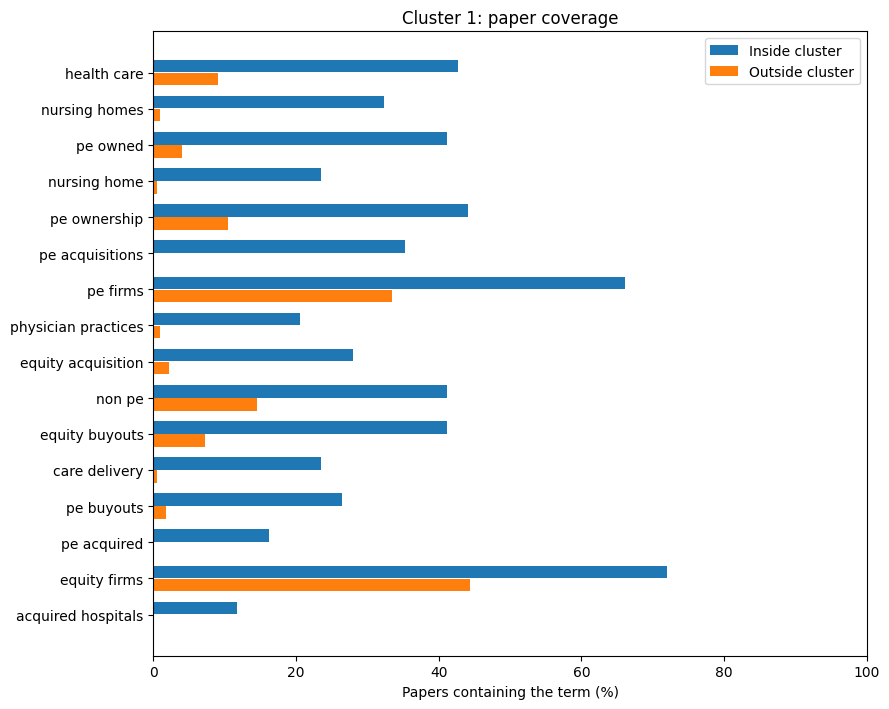

In [8]:
selected_terms = ranked_terms(analysis, CLUSTER, RANKING, TERM_KIND, TOP_N)
if not selected_terms.empty:
    plot_rows = selected_terms.iloc[::-1]
    y = np.arange(len(plot_rows))
    fig, ax = plt.subplots(figsize=(9, max(3, 0.45 * len(plot_rows))))
    ax.barh(y + 0.18, 100 * plot_rows.inside_prevalence, height=0.35, label='Inside cluster')
    ax.barh(y - 0.18, 100 * plot_rows.outside_prevalence, height=0.35, label='Outside cluster')
    ax.set(yticks=y, yticklabels=plot_rows.term, xlim=(0, 100),
           xlabel='Papers containing the term (%)', title=f'Cluster {CLUSTER}: paper coverage')
    ax.legend()
    fig.tight_layout()
    plt.show()

### Paper examples and possible counterexamples

Up to three representatives have the most citation links within their community,
with incoming citations used to break ties. Up to two boundary candidates have
the greatest share of links going to other communities. A disconnected community
has no external-link boundary candidates. Up to two further papers are sampled
with a fixed seed; a paper may have more than one role.

These are **citation-based review criteria**. Expand a paper to inspect its retained
PDF excerpt and page. Excerpts are usually selected around ranked terms and help
interpretation; they do not replace reading the paper. Citation centrality does
not establish thematic representativeness on its own.


In [9]:
review = analysis['examples'].loc[analysis['examples'].cluster == CLUSTER]
display(review[['paper_id', 'title', 'selection', 'within_community_degree', 'external_link_fraction']].style.hide(axis='index')
        .format({'external_link_fraction': '{:.1%}'}).set_properties(**{'white-space': 'normal'}))
for paper in review.itertuples():
    heading = escape(f'{paper.paper_id} — {paper.title} ({paper.selection})')
    location = escape(f'PDF page {paper.page}; block {paper.block_id}; selected term: {paper.term or "none"}')
    display(HTML(f'<details><summary>{heading}</summary><p>{location}</p>'
                 f'<p style="white-space:pre-wrap">{escape(paper.excerpt)}</p></details>'))

paper_id,title,selection,within_community_degree,external_link_fraction
P116,"Private equity, jobs, and productivity",representative,35,18.6%
P040,The Operational Consequences of Private Equity Buyouts: Evidence from the Restaurant Industry,representative,30,34.8%
P053,Growth LBOs,representative,29,32.6%
P165,Contracts with (Social) benefits: The implementation of impact investing,boundary,3,70.0%
P127,Can Limited Partners Mitigate Negative Externalities in Private Equity,boundary,11,66.7%
P207,Private equity ownership and nursing home quality: an instrumental variables approach,random,10,41.2%
P159,"Eileen Appelbaum and Rosemary Batt, Private Equity at Work: When Wall Street Manages Main Street, New York, Russel Sage Foundation, 2014",random,1,0.0%


## 7 Trace a specific expression to its papers

Copy an exact term from a table into `EXPRESSION`, or leave it as `None` to use the
first term in the selected cluster/ranking. Support uses the whole-word search from section 3, including hyphen normalization.
Ranked expressions use the same contiguous wording. Each paper counts once for coverage;
the occurrence count is provided separately. Supporting papers outside the cluster
help distinguish a specific theme from vocabulary shared across the literature.

In [10]:
EXPRESSION = None               # For example, copy an expression from your table.
SUPPORT_ROWS = 20              # Display limit only; export includes every supporting paper.
selected_terms = ranked_terms(analysis, CLUSTER, RANKING, TERM_KIND, TOP_N)
selected_expression = EXPRESSION or (selected_terms.iloc[0].term if len(selected_terms) else None)
support = None
if selected_expression is None:
    print('No eligible term in this view. Choose another cluster or term kind.')
else:
    support = supporting_papers(analysis, selected_expression, CLUSTER)
    n_inside = int((analysis['labels'] == CLUSTER).sum())
    print(f'Expression: {selected_expression}')
    print(f'Inside: {support.inside.sum()}/{n_inside}; outside: {(~support.inside).sum()}/{len(analysis["papers"]) - n_inside}')
    for inside, title in [(True, 'Inside cluster'), (False, 'Outside cluster')]:
        group = support.loc[support.inside == inside]
        display(Markdown(f'### {title}: showing {min(SUPPORT_ROWS, len(group))} of {len(group)} supporting papers'))
        display(group[['paper_id', 'title', 'cluster', 'occurrences', 'page']].head(SUPPORT_ROWS)
                .style.hide(axis='index').set_properties(**{'white-space': 'normal'}))

Expression: health care
Inside: 29/68; outside: 19/221


### Inside cluster: showing 20 of 29 supporting papers

paper_id,title,cluster,occurrences,page
P008,Private Equity and Workers' Career Paths: The Role of Technological Change,1,2,10
P016,"Private Equity Buyouts in Healthcare Who Wins, Who Loses",1,105,2
P050,"Evaluating trends in private equity ownership and impacts on health outcomes, costs, and quality: systematic review",1,21,15
P051,What happens to a nursing home chain when private equity takes over? A longitudinal case study,1,9,1
P060,Comparative Performance of Private Equity-Owned US Nursing Homes during the COVID-19 Pandemic,1,3,2
P061,Association of Private Equity Investment in US Nursing Homes with the Quality and Cost of Care for Long-Stay Residents,1,3,2
P066,Private Equity Investment in Behavioral Health Treatment Centers,1,7,1
P069,"Changes in Hospital Income, Use, and Quality Associated with Private Equity Acquisition",1,16,1
P070,Expansion of Private Equity Involvement in Women's Health Care,1,13,1
P071,"Private Equity Acquisitions Of Ambulatory Surgical Centers Were Not Associated With Quality, Cost, Or Volume Changes",1,15,1


### Outside cluster: showing 19 of 19 supporting papers

paper_id,title,cluster,occurrences,page
P010,Private equity in the global economy: Evidence on industry spillovers,2,4,5
P029,Impact investing,4,6,5
P033,Fee Variation in Private Equity,4,1,6
P057,How persistent is private equity performance? Evidence from deal-level data,4,1,12
P059,Adverse selection and the performance of private equity co-investments,4,2,7
P067,Private equity portfolio companies A first look at Burgiss holdings data,4,2,28
P084,"Employee buyouts: causes, structure, and consequences",2,3,37
P138,Venture Capital and Other Private Equity: A Survey,2,1,11
P151,New resources and new ideas: Private equity for small businesses,3,1,2
P152,The Performance of Private Equity-Backed IPOs,2,1,9


In [11]:
PAPER_ID = None                 # Copy a paper_id above, or inspect the first supporting paper.
if support is not None and len(support):
    inspected = support.iloc[0] if PAPER_ID is None else support.set_index('paper_id').loc[PAPER_ID]
    display(Markdown(f'**PDF page {inspected.page} — source block**'))
    display(HTML(f'<p>{escape(inspected.title)}</p><pre style="white-space:pre-wrap">'
                 f'{escape(inspected.passage)}</pre>'))

**PDF page 10 — source block**

## 8 Save evidence for your interpretation

Set `SAVE_RESULTS = True` when you want a permanent record. Each export creates a new
folder under `outputs/topic_analysis_citations_v2`; previous evidence is never replaced.

It contains full eligible word/expression rankings for both methods, cluster sizes,
complete citation membership (including isolates), graph-based review papers with
PDF excerpts, excluded isolates, supporting papers for
the selected expression, and a manifest of parameters, input hashes and software versions.
Scores and proportions are saved at full precision. Plot display is not required for reproduction.

When you later name a cluster, record which expressions and papers support the name,
which papers challenge it, and the exported run folder. Inspect table noise (for example
“yes yes”), broad methodological vocabulary, synonyms and mixed subject matter before
interpreting a ranking. A descriptive label should remain open to revision.

In [12]:
SAVE_RESULTS = False
if SAVE_RESULTS:
    exported = export_analysis(analysis, context, partition_settings, support=support,
        display_settings=dict(cluster=CLUSTER, ranking=RANKING, kind=TERM_KIND,
                              top_n=TOP_N, detail_top_n=DETAIL_TOP_N, expression=selected_expression))
    print('Saved evidence:', exported)
else:
    print('Full expression-evidence export disabled. Set SAVE_RESULTS = True to save it.')

Full expression-evidence export disabled. Set SAVE_RESULTS = True to save it.
